# ObjChange-MambaDiff: Full Research Notebook

**Research title:** Object-Aware Foundation-Mamba Diffusion Network for Label-Efficient Multi-Temporal Satellite Image Change Detection

This notebook implements a complete runnable research pipeline based on your proposal:

- Dataset discovery and auditing under `D:\Datasets\Satillate`
- Unified loaders for LEVIR-CD, WHU-CD, DSIFN-CD, CDD, SECOND, HRSCD, xView2/xBD, and S2Looking where present
- Baseline Siamese U-Net
- Proposed **ObjChange-MambaDiff-Lite** model:
  - shared/foundation-style encoder
  - cross-temporal interaction
  - object-token pooling branch
  - Mamba-inspired temporal memory block with safe fallback
  - uncertainty-aware dropout head
  - diffusion-style pseudo-change pretraining through controlled synthetic edits
- Label-efficiency experiments
- Cross-dataset testing
- xView2/xBD JSON-to-mask preprocessing helper
- Metrics, ablation tables, qualitative figures, and reproducibility outputs

The notebook starts with safe quick-run settings. After it works, switch `QUICK_RUN=False` for publication-level benchmarking.

In [1]:
# ============================================================
# 0. Optional installation cell
# ============================================================
# Run this only if needed.
#
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install numpy pandas pillow matplotlib scikit-learn tqdm opencv-python albumentations rasterio shapely pyproj
# !pip install timm segmentation-models-pytorch
#
# Optional for official Mamba:
# !pip install mamba-ssm

In [2]:
# ============================================================
# 1. Imports and global configuration
# ============================================================
import os
import re
import json
import math
import time
import random
import warnings
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

ROOT = Path(r"D:\Datasets\Satillate")
PROJECT_DIR = ROOT / "_objchange_mambadiff_project"
REPORT_DIR = PROJECT_DIR / "reports"
CACHE_DIR = PROJECT_DIR / "cache"
CKPT_DIR = PROJECT_DIR / "checkpoints"
FIG_DIR = PROJECT_DIR / "figures"
PRED_DIR = PROJECT_DIR / "qualitative_predictions"

for d in [PROJECT_DIR, REPORT_DIR, CACHE_DIR, CKPT_DIR, FIG_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Safe first run. For full research: QUICK_RUN=False, EPOCHS=50, MAX_SAMPLES_PER_SPLIT=None.
QUICK_RUN = True
RUN_TRAINING = True

IMG_SIZE = 256
BATCH_SIZE = 4 if QUICK_RUN else 8
NUM_WORKERS = 0  # safer on Windows/Jupyter; set 2-4 if stable
EPOCHS = 2 if QUICK_RUN else 50
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_SAMPLES_PER_SPLIT = 64 if QUICK_RUN else None

PRIMARY_BINARY_DATASETS = ["LEVIR-CD", "S2Looking", "DSIFN-CD", "CDD"]
SEMANTIC_DATASETS = ["SECOND", "HRSCD"]
DISASTER_DATASETS = ["xView2"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("ROOT:", ROOT)
print("PROJECT_DIR:", PROJECT_DIR)
print("DEVICE:", DEVICE)
print("QUICK_RUN:", QUICK_RUN)

ROOT: D:\Datasets\Satillate
PROJECT_DIR: D:\Datasets\Satillate\_objchange_mambadiff_project
DEVICE: cuda
QUICK_RUN: True


## 2. Dataset discovery and audit

The proposal groups datasets as:

| Group | Datasets |
|---|---|
| Binary building change | LEVIR-CD, WHU-CD |
| General / seasonal change | DSIFN-CD, CDD |
| Semantic change | SECOND, HRSCD |
| Disaster change | xBD / xView2 |
| Viewpoint robustness | S2Looking |

In [3]:
# ============================================================
# 2. Dataset discovery helpers
# ============================================================
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".webp"}
ANNOT_EXTS = {".json", ".geojson", ".xml", ".txt", ".csv", ".shp"}

DATASET_PATTERNS = {
    "LEVIR-CD": [r"levir"],
    "WHU-CD": [r"whu"],
    "DSIFN-CD": [r"dsifn"],
    "CDD": [r"\bcdd\b", r"change detection dataset", r"building change detection dataset_add"],
    "SECOND": [r"\bsecond\b", r"second_dataset"],
    "HRSCD": [r"hrscd"],
    "xView2": [r"xview2", r"xbd"],
    "S2Looking": [r"s2looking", r"s2 looking"],
}

GROUP_MAP = {
    "LEVIR-CD": "binary_building_change",
    "WHU-CD": "binary_building_change",
    "DSIFN-CD": "general_seasonal_change",
    "CDD": "general_seasonal_change",
    "SECOND": "semantic_change",
    "HRSCD": "semantic_change",
    "xView2": "disaster_change",
    "S2Looking": "viewpoint_robustness",
}

TASK_MAP = {
    "LEVIR-CD": "binary",
    "WHU-CD": "binary",
    "DSIFN-CD": "binary",
    "CDD": "binary",
    "SECOND": "semantic",
    "HRSCD": "semantic",
    "xView2": "disaster",
    "S2Looking": "binary",
}

def normalise_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", s.lower()).strip()

def infer_dataset_name(path: Path) -> Optional[str]:
    p = normalise_name(str(path))
    for ds, pats in DATASET_PATTERNS.items():
        for pat in pats:
            if re.search(pat, p):
                return ds
    return None

def find_dataset_roots(root: Path) -> pd.DataFrame:
    rows = []
    if not root.exists():
        print(f"Root does not exist: {root}")
        return pd.DataFrame()
    candidates = [root] + [p for p in root.iterdir() if p.is_dir()]
    for p in list(candidates):
        try:
            candidates += [q for q in p.iterdir() if q.is_dir()]
        except Exception:
            pass
    seen = set()
    for p in candidates:
        if str(p) in seen:
            continue
        seen.add(str(p))
        ds = infer_dataset_name(p)
        if ds:
            rows.append({
                "dataset": ds,
                "path": str(p),
                "folder_name": p.name,
                "group": GROUP_MAP.get(ds),
                "task": TASK_MAP.get(ds),
            })
    df = pd.DataFrame(rows).drop_duplicates()
    if not df.empty:
        df["depth"] = df["path"].apply(lambda x: len(Path(x).parts))
        df = df.sort_values(["dataset", "depth", "path"]).reset_index(drop=True)
    return df

dataset_roots_df = find_dataset_roots(ROOT)
dataset_roots_df.to_csv(REPORT_DIR / "detected_dataset_roots.csv", index=False)
dataset_roots_df

,dataset,path,folder_name,group,task,depth
0,CDD,D:\Datasets\Satillate\Building change detectio...,Building change detection dataset_add,general_seasonal_change,binary,4
1,CDD,D:\Datasets\Satillate\Building change detectio...,1. The two-period image data,general_seasonal_change,binary,5
2,CDD,D:\Datasets\Satillate\Building change detectio...,2. The shape file of the images,general_seasonal_change,binary,5
3,DSIFN-CD,D:\Datasets\Satillate\DSIFN Train Test,DSIFN Train Test,general_seasonal_change,binary,4
4,DSIFN-CD,D:\Datasets\Satillate\DSIFN Train Test\test,test,general_seasonal_change,binary,5
5,DSIFN-CD,D:\Datasets\Satillate\DSIFN Train Test\train,train,general_seasonal_change,binary,5
6,HRSCD,D:\Datasets\Satillate\HRSCD,HRSCD,semantic_change,semantic,4
7,HRSCD,D:\Datasets\Satillate\HRSCD\images_2012,images_2012,semantic_change,semantic,5
8,HRSCD,D:\Datasets\Satillate\HRSCD\labels_change,labels_change,semantic_change,semantic,5
9,HRSCD,D:\Datasets\Satillate\HRSCD\labels_land_cover_...,labels_land_cover_2006,semantic_change,semantic,5


In [4]:
# ============================================================
# 3. Inventory files under detected dataset roots
# ============================================================
def safe_file_size(p: Path) -> int:
    try:
        return p.stat().st_size
    except Exception:
        return 0

def infer_split_from_path(p: Path) -> str:
    parts = [normalise_name(x) for x in p.parts]
    joined = " ".join(parts)
    if any(x in parts for x in ["train", "training"]):
        return "train"
    if any(x in parts for x in ["val", "valid", "validation"]):
        return "val"
    if any(x in parts for x in ["test", "testing"]):
        return "test"
    if "hold" in joined:
        return "test"
    return "unknown"

def classify_role_from_path(p: Path) -> str:
    parts = [normalise_name(x) for x in p.parts]
    joined = " ".join(parts)
    parent = normalise_name(p.parent.name)
    name_lower = p.name.lower()
    stem = normalise_name(p.stem)

    if "pre_disaster" in name_lower or "_pre_" in name_lower:
        return "t1"
    if "post_disaster" in name_lower or "_post_" in name_lower:
        return "t2"

    if re.search(r"(label|mask|gt|ground truth|change)", joined):
        if re.search(r"(2006|t1|time1|label1|before|pre)", joined):
            return "sem_t1"
        if re.search(r"(2012|t2|time2|label2|after|post)", joined):
            return "sem_t2"
        return "mask"

    t1_tokens = {"a", "a1", "image1", "im1", "t1", "time1", "before", "pre", "img1", "imgs1", "images1"}
    t2_tokens = {"b", "b1", "image2", "im2", "t2", "time2", "after", "post", "img2", "imgs2", "images2"}

    if parent in t1_tokens or re.search(r"(image1|im1|img1|t1|before|pre)", joined):
        return "t1"
    if parent in t2_tokens or re.search(r"(image2|im2|img2|t2|after|post)", joined):
        return "t2"

    return "image_unknown"

def inventory_dataset(dataset: str, root_path: Path, max_files: Optional[int]=None) -> pd.DataFrame:
    rows = []
    n = 0
    for p in root_path.rglob("*"):
        if not p.is_file():
            continue
        ext = p.suffix.lower()
        if ext not in IMAGE_EXTS and ext not in ANNOT_EXTS:
            continue
        role = classify_role_from_path(p) if ext in IMAGE_EXTS else "annotation"
        rows.append({
            "dataset": dataset,
            "group": GROUP_MAP.get(dataset),
            "task": TASK_MAP.get(dataset),
            "path": str(p),
            "rel_path": str(p.relative_to(root_path)),
            "filename": p.name,
            "stem": p.stem,
            "ext": ext,
            "split": infer_split_from_path(p),
            "role": role,
            "size_bytes": safe_file_size(p),
        })
        n += 1
        if max_files and n >= max_files:
            break
    return pd.DataFrame(rows)

all_inv = []
for _, row in dataset_roots_df.iterrows():
    all_inv.append(inventory_dataset(row["dataset"], Path(row["path"])))

inventory_df = pd.concat(all_inv, ignore_index=True) if all_inv else pd.DataFrame()
inventory_df.to_csv(REPORT_DIR / "full_inventory.csv", index=False)

summary_ext = inventory_df.groupby(["dataset", "ext"]).size().reset_index(name="count") if not inventory_df.empty else pd.DataFrame()
summary_role = inventory_df.groupby(["dataset", "split", "role"]).size().reset_index(name="count") if not inventory_df.empty else pd.DataFrame()
summary_ext.to_csv(REPORT_DIR / "extension_summary.csv", index=False)
summary_role.to_csv(REPORT_DIR / "role_split_summary.csv", index=False)

print("Inventory rows:", len(inventory_df))
summary_role.head(40)

Inventory rows: 243371


,dataset,split,role,count
0,CDD,test,annotation,22
1,CDD,test,mask,2766
2,CDD,test,sem_t2,2764
3,CDD,train,annotation,22
4,CDD,train,mask,5046
5,CDD,train,sem_t2,5044
6,DSIFN-CD,test,mask,6300
7,DSIFN-CD,test,sem_t1,2
8,DSIFN-CD,test,sem_t2,4
9,DSIFN-CD,test,t1,6306


## 3. Unified sample table

The next cells pair `t1`, `t2`, and `mask` files. Some datasets, especially HRSCD and xView2, may still need dataset-specific preprocessing.

In [5]:
# ============================================================
# 4. Build unified paired sample table
# ============================================================
def clean_pair_key(stem: str) -> str:
    s = stem.lower()
    s = re.sub(r"(_pre_disaster|_post_disaster|pre_disaster|post_disaster)", "", s)
    s = re.sub(r"(^a_|^b_|_a$|_b$|^image1_|^image2_|^im1_|^im2_|^img1_|^img2_)", "", s)
    s = re.sub(r"[^a-z0-9]+", "_", s).strip("_")
    return s

def build_pairs_for_dataset(inv: pd.DataFrame) -> pd.DataFrame:
    if inv.empty:
        return pd.DataFrame()
    dataset = inv["dataset"].iloc[0]
    rows = []
    images = inv[inv["ext"].isin(IMAGE_EXTS)].copy()
    if images.empty:
        return pd.DataFrame()
    images["key"] = images["stem"].apply(clean_pair_key)

    for split, sdf in images.groupby("split"):
        by_role = {}
        for role in ["t1", "t2", "mask", "sem_t1", "sem_t2"]:
            tmp = sdf[sdf["role"] == role]
            by_role[role] = {r["key"]: r["path"] for _, r in tmp.iterrows()}
        keys = set(by_role["t1"].keys()) & set(by_role["t2"].keys())
        for k in sorted(keys):
            rows.append({
                "dataset": dataset,
                "group": GROUP_MAP.get(dataset),
                "task": TASK_MAP.get(dataset),
                "split": split,
                "key": k,
                "image_t1": by_role["t1"].get(k),
                "image_t2": by_role["t2"].get(k),
                "binary_mask": by_role["mask"].get(k),
                "semantic_t1": by_role["sem_t1"].get(k),
                "semantic_t2": by_role["sem_t2"].get(k),
                "annotation_json": None,
            })
    return pd.DataFrame(rows)

pairs = []
for ds, ds_inv in inventory_df.groupby("dataset"):
    pairs.append(build_pairs_for_dataset(ds_inv))

samples_df = pd.concat(pairs, ignore_index=True) if pairs else pd.DataFrame()

def attach_xview2_json(samples_df: pd.DataFrame, inv: pd.DataFrame) -> pd.DataFrame:
    if samples_df.empty or "xView2" not in samples_df["dataset"].values:
        return samples_df
    ann = inv[(inv["dataset"] == "xView2") & (inv["ext"].isin([".json", ".geojson"]))].copy()
    if ann.empty:
        return samples_df
    ann["key"] = ann["stem"].apply(clean_pair_key)
    ann_map = {r["key"]: r["path"] for _, r in ann.iterrows()}
    mask = samples_df["dataset"] == "xView2"
    samples_df.loc[mask, "annotation_json"] = samples_df.loc[mask, "key"].map(ann_map)
    return samples_df

samples_df = attach_xview2_json(samples_df, inventory_df)
samples_df.to_csv(REPORT_DIR / "unified_samples.csv", index=False)

print("Paired samples:", len(samples_df))
if len(samples_df):
    display(samples_df.groupby(["dataset", "split"]).size().reset_index(name="pairs"))
    display(samples_df.head())

Paired samples: 28862


,dataset,split,pairs
0,DSIFN-CD,test,3153
1,DSIFN-CD,train,12611
2,LEVIR-CD,test,128
3,LEVIR-CD,train,445
4,LEVIR-CD,val,64
5,S2Looking,test,1000
6,S2Looking,train,3500
7,S2Looking,val,500
8,SECOND,test,1694
9,SECOND,train,2968


,dataset,group,task,split,key,image_t1,image_t2,binary_mask,semantic_t1,semantic_t2,annotation_json
0,DSIFN-CD,general_seasonal_change,binary,test,0_1,D:\Datasets\Satillate\DSIFN Train Test\test\A\...,D:\Datasets\Satillate\DSIFN Train Test\test\B\...,D:\Datasets\Satillate\DSIFN Train Test\test\la...,None,None,None
1,DSIFN-CD,general_seasonal_change,binary,test,0_4,D:\Datasets\Satillate\DSIFN Train Test\test\A\...,D:\Datasets\Satillate\DSIFN Train Test\test\B\...,D:\Datasets\Satillate\DSIFN Train Test\test\la...,None,None,None
2,DSIFN-CD,general_seasonal_change,binary,test,1001_1,D:\Datasets\Satillate\DSIFN Train Test\test\A\...,D:\Datasets\Satillate\DSIFN Train Test\test\B\...,D:\Datasets\Satillate\DSIFN Train Test\test\la...,None,None,None
3,DSIFN-CD,general_seasonal_change,binary,test,1002_3,D:\Datasets\Satillate\DSIFN Train Test\test\A\...,D:\Datasets\Satillate\DSIFN Train Test\test\B\...,D:\Datasets\Satillate\DSIFN Train Test\test\la...,None,None,None
4,DSIFN-CD,general_seasonal_change,binary,test,1002_4,D:\Datasets\Satillate\DSIFN Train Test\test\A\...,D:\Datasets\Satillate\DSIFN Train Test\test\B\...,D:\Datasets\Satillate\DSIFN Train Test\test\la...,None,None,None


In [6]:
# ============================================================
# 5. Manual fallback pairing for common folder structures
# ============================================================
def find_dirs_by_name(root: Path, names: List[str]) -> List[Path]:
    names_norm = [normalise_name(n) for n in names]
    out = []
    for p in root.rglob("*"):
        if p.is_dir() and normalise_name(p.name) in names_norm:
            out.append(p)
    return out

def list_images(d: Path) -> List[Path]:
    if not d or not d.exists():
        return []
    return sorted([p for p in d.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

def pair_from_dirs(dataset: str, root: Path, t1_names, t2_names, mask_names, split_hint: str="unknown") -> pd.DataFrame:
    rows = []
    t1_dirs = find_dirs_by_name(root, t1_names)
    t2_dirs = find_dirs_by_name(root, t2_names)
    mask_dirs = find_dirs_by_name(root, mask_names)
    for d1 in t1_dirs:
        parent = d1.parent
        sibling_t2 = [d for d in t2_dirs if d.parent == parent] or t2_dirs
        sibling_m = [d for d in mask_dirs if d.parent == parent] or mask_dirs
        for d2 in sibling_t2[:1]:
            t1_map = {clean_pair_key(p.stem): p for p in list_images(d1)}
            t2_map = {clean_pair_key(p.stem): p for p in list_images(d2)}
            m_map = {}
            if sibling_m:
                for md in sibling_m:
                    m_map.update({clean_pair_key(p.stem): p for p in list_images(md)})
            keys = sorted(set(t1_map) & set(t2_map))
            split = infer_split_from_path(d1)
            if split == "unknown":
                split = split_hint
            for k in keys:
                rows.append({
                    "dataset": dataset, "group": GROUP_MAP.get(dataset), "task": TASK_MAP.get(dataset),
                    "split": split, "key": k,
                    "image_t1": str(t1_map[k]), "image_t2": str(t2_map[k]),
                    "binary_mask": str(m_map[k]) if k in m_map else None,
                    "semantic_t1": None, "semantic_t2": None, "annotation_json": None
                })
    return pd.DataFrame(rows)

def add_manual_pairs(samples_df: pd.DataFrame, dataset_roots_df: pd.DataFrame) -> pd.DataFrame:
    manual = []
    configs = {
        "LEVIR-CD": (["A", "image1", "im1", "t1"], ["B", "image2", "im2", "t2"], ["label", "labels", "mask", "gt"]),
        "S2Looking": (["Image1", "im1", "A"], ["Image2", "im2", "B"], ["label", "labels", "mask"]),
        "DSIFN-CD": (["t1", "A", "im1", "image1"], ["t2", "B", "im2", "image2"], ["label", "labels", "mask"]),
        "CDD": (["A", "t1", "image1"], ["B", "t2", "image2"], ["label", "labels", "mask", "OUT"]),
        "SECOND": (["im1", "img1", "image1", "A"], ["im2", "img2", "image2", "B"], ["label1", "label2", "label", "labels"]),
    }
    for ds, cfg in configs.items():
        roots = dataset_roots_df[dataset_roots_df["dataset"] == ds]["path"].tolist()
        for rp in roots:
            df = pair_from_dirs(ds, Path(rp), *cfg)
            if len(df):
                manual.append(df)
    if manual:
        mdf = pd.concat(manual, ignore_index=True)
        combined = pd.concat([samples_df, mdf], ignore_index=True) if len(samples_df) else mdf
        combined = combined.drop_duplicates(subset=["dataset", "split", "key", "image_t1", "image_t2"]).reset_index(drop=True)
        return combined
    return samples_df

samples_df = add_manual_pairs(samples_df, dataset_roots_df)
samples_df.to_csv(REPORT_DIR / "unified_samples_after_manual_pairing.csv", index=False)

print("Paired samples after manual heuristics:", len(samples_df))
if len(samples_df):
    display(samples_df.groupby(["dataset", "split"]).size().reset_index(name="pairs"))

Paired samples after manual heuristics: 30556


,dataset,split,pairs
0,DSIFN-CD,test,3153
1,DSIFN-CD,train,12611
2,LEVIR-CD,test,128
3,LEVIR-CD,train,445
4,LEVIR-CD,val,64
5,S2Looking,test,1000
6,S2Looking,train,3500
7,S2Looking,val,500
8,SECOND,test,3388
9,SECOND,train,2968


## 4. xView2 / xBD JSON-to-mask preprocessing

xView2 annotations are JSON polygon files. This helper converts building/damage polygons into masks:

- `0`: background
- `1`: no-damage / building
- `2`: minor damage
- `3`: major damage
- `4`: destroyed

In [7]:
# ============================================================
# 6. xView2 JSON annotation to raster mask helper
# ============================================================
DAMAGE_MAP = {
    "no-damage": 1,
    "minor-damage": 2,
    "major-damage": 3,
    "destroyed": 4,
    "un-classified": 1,
}

def parse_wkt_polygon(wkt: str) -> List[Tuple[float, float]]:
    nums = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", wkt)
    vals = list(map(float, nums))
    return list(zip(vals[0::2], vals[1::2]))

def xview2_json_to_mask(json_path: Path, image_path: Path, out_path: Path, binary: bool=False) -> Optional[Path]:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        img = Image.open(image_path)
        w, h = img.size
        mask = Image.new("L", (w, h), 0)
        draw = ImageDraw.Draw(mask)

        features = data.get("features", {})
        xy_features = features.get("xy", []) if isinstance(features, dict) else []
        for feat in xy_features:
            props = feat.get("properties", {})
            subtype = props.get("subtype", "no-damage")
            val = DAMAGE_MAP.get(subtype, 1)
            if binary:
                val = 1
            wkt = feat.get("wkt", "")
            if "POLYGON" not in wkt:
                continue
            pts = parse_wkt_polygon(wkt)
            if len(pts) >= 3:
                draw.polygon(pts, fill=val)

        out_path.parent.mkdir(parents=True, exist_ok=True)
        mask.save(out_path)
        return out_path
    except Exception as e:
        print("Failed:", json_path, e)
        return None

def preprocess_xview2_masks(samples_df: pd.DataFrame, max_items: Optional[int]=None, binary: bool=True) -> pd.DataFrame:
    df = samples_df.copy()
    mask_rows = df[(df["dataset"] == "xView2") & df["annotation_json"].notna()]
    if max_items:
        mask_rows = mask_rows.head(max_items)
    created = {}
    for idx, row in tqdm(mask_rows.iterrows(), total=len(mask_rows), desc="xView2 JSON -> mask"):
        img_path = Path(row["image_t2"])
        ann_path = Path(row["annotation_json"])
        out_path = CACHE_DIR / "xview2_masks" / ("binary" if binary else "damage") / f"{row['key']}.png"
        res = xview2_json_to_mask(ann_path, img_path, out_path, binary=binary)
        if res:
            created[idx] = str(res)
    for idx, m in created.items():
        df.loc[idx, "binary_mask"] = m
    return df

# Uncomment if you want to create xView2 masks before training:
# samples_df = preprocess_xview2_masks(samples_df, max_items=MAX_SAMPLES_PER_SPLIT if QUICK_RUN else None, binary=True)
# samples_df.to_csv(REPORT_DIR / "unified_samples_with_xview2_masks.csv", index=False)

## 5. PyTorch dataset

Supports binary masks, semantic-label difference masks, pseudo-change generation, and basic augmentation.

In [8]:
# ============================================================
# 7. Dataset class
# ============================================================
def pil_read_rgb(path: str, size: int=IMG_SIZE) -> Image.Image:
    img = Image.open(path).convert("RGB")
    if size:
        img = img.resize((size, size), resample=Image.BILINEAR)
    return img

def pil_read_mask(path: str, size: int=IMG_SIZE) -> Image.Image:
    m = Image.open(path).convert("L")
    if size:
        m = m.resize((size, size), resample=Image.NEAREST)
    return m

class ChangeDetectionDataset(Dataset):
    def __init__(self, samples: pd.DataFrame, img_size: int=256, train: bool=False, pseudo_change: bool=False, return_meta: bool=False):
        self.samples = samples.reset_index(drop=True)
        self.img_size = img_size
        self.train = train
        self.pseudo_change = pseudo_change
        self.return_meta = return_meta
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.samples)

    def _augment(self, a, b, m):
        if not self.train:
            return a, b, m
        if random.random() < 0.5:
            a = transforms.functional.hflip(a); b = transforms.functional.hflip(b); m = transforms.functional.hflip(m)
        if random.random() < 0.5:
            a = transforms.functional.vflip(a); b = transforms.functional.vflip(b); m = transforms.functional.vflip(m)
        if random.random() < 0.25:
            angle = random.choice([90, 180, 270])
            a = transforms.functional.rotate(a, angle); b = transforms.functional.rotate(b, angle); m = transforms.functional.rotate(m, angle)
        return a, b, m

    def _make_pseudo_change(self, a: Image.Image) -> Tuple[Image.Image, Image.Image]:
        b = a.copy()
        mask = Image.new("L", a.size, 0)
        draw_b = ImageDraw.Draw(b)
        draw_m = ImageDraw.Draw(mask)
        w, h = a.size
        n_obj = random.randint(1, 5)
        for _ in range(n_obj):
            shape = random.choice(["rect", "ellipse", "line"])
            x1 = random.randint(0, max(1, w-40))
            y1 = random.randint(0, max(1, h-40))
            x2 = min(w, x1 + random.randint(12, max(16, w//4)))
            y2 = min(h, y1 + random.randint(12, max(16, h//4)))
            color = tuple(np.random.randint(30, 230, size=3).tolist())
            if shape == "rect":
                draw_b.rectangle([x1, y1, x2, y2], fill=color)
                draw_m.rectangle([x1, y1, x2, y2], fill=255)
            elif shape == "ellipse":
                draw_b.ellipse([x1, y1, x2, y2], fill=color)
                draw_m.ellipse([x1, y1, x2, y2], fill=255)
            else:
                width = random.randint(3, 10)
                draw_b.line([x1, y1, x2, y2], fill=color, width=width)
                draw_m.line([x1, y1, x2, y2], fill=255, width=width)
        return b, mask

    def __getitem__(self, idx):
        row = self.samples.iloc[idx]
        a = pil_read_rgb(row["image_t1"], self.img_size)

        if self.pseudo_change:
            b, m = self._make_pseudo_change(a)
        else:
            b = pil_read_rgb(row["image_t2"], self.img_size)
            mask_path = row.get("binary_mask", None)
            if pd.isna(mask_path) or mask_path is None or not str(mask_path):
                s1, s2 = row.get("semantic_t1", None), row.get("semantic_t2", None)
                if s1 and s2 and not pd.isna(s1) and not pd.isna(s2):
                    m1 = np.array(pil_read_mask(s1, self.img_size))
                    m2 = np.array(pil_read_mask(s2, self.img_size))
                    m = Image.fromarray(((m1 != m2).astype(np.uint8) * 255))
                else:
                    m = Image.new("L", (self.img_size, self.img_size), 0)
            else:
                m = pil_read_mask(mask_path, self.img_size)

        a, b, m = self._augment(a, b, m)
        a_t = self.to_tensor(a)
        b_t = self.to_tensor(b)
        m_t = (self.to_tensor(m) > 0).float()

        item = {"image_t1": a_t, "image_t2": b_t, "mask": m_t}
        if self.return_meta:
            item["meta"] = {"dataset": row["dataset"], "split": row["split"], "key": row["key"]}
        return item

def make_split_df(samples_df: pd.DataFrame, dataset: str, split: str, require_mask: bool=True, max_samples=None):
    df = samples_df[(samples_df["dataset"] == dataset) & (samples_df["split"] == split)].copy()
    if require_mask:
        df = df[df["binary_mask"].notna() | (df["semantic_t1"].notna() & df["semantic_t2"].notna())]
    if len(df) == 0 and split == "val":
        tr = samples_df[(samples_df["dataset"] == dataset) & (samples_df["split"] == "train")].copy()
        if require_mask:
            tr = tr[tr["binary_mask"].notna() | (tr["semantic_t1"].notna() & tr["semantic_t2"].notna())]
        if len(tr):
            df = tr.sample(frac=0.2, random_state=SEED)
    if len(df) == 0 and split == "test":
        df = samples_df[(samples_df["dataset"] == dataset) & (samples_df["split"].isin(["val", "unknown"]))].copy()
        if require_mask:
            df = df[df["binary_mask"].notna() | (df["semantic_t1"].notna() & df["semantic_t2"].notna())]
    if max_samples and len(df) > max_samples:
        df = df.sample(n=max_samples, random_state=SEED)
    return df.reset_index(drop=True)

available_train = samples_df.groupby(["dataset", "split"]).size().reset_index(name="n") if len(samples_df) else pd.DataFrame()
available_train

,dataset,split,n
0,DSIFN-CD,test,3153
1,DSIFN-CD,train,12611
2,LEVIR-CD,test,128
3,LEVIR-CD,train,445
4,LEVIR-CD,val,64
5,S2Looking,test,1000
6,S2Looking,train,3500
7,S2Looking,val,500
8,SECOND,test,3388
9,SECOND,train,2968


## 6. Models

Two models are included:

1. **SiameseUNetBaseline**  
2. **ObjChangeMambaDiffLite** with object tokens, cross-time attention, Mamba-like token memory, pseudo-change pretraining support, and uncertainty dropout.

In [9]:
# ============================================================
# 8. Model blocks
# ============================================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )
    def forward(self, x):
        return self.net(x)

class EncoderSmall(nn.Module):
    def __init__(self, in_ch=3, base=32, dropout=0.0):
        super().__init__()
        self.c1 = ConvBlock(in_ch, base, dropout)
        self.c2 = ConvBlock(base, base*2, dropout)
        self.c3 = ConvBlock(base*2, base*4, dropout)
        self.c4 = ConvBlock(base*4, base*8, dropout)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        f1 = self.c1(x)
        f2 = self.c2(self.pool(f1))
        f3 = self.c3(self.pool(f2))
        f4 = self.c4(self.pool(f3))
        return [f1, f2, f3, f4]

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch, dropout)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class SimpleMambaLikeBlock(nn.Module):
    def __init__(self, dim, expansion=2, kernel_size=5):
        super().__init__()
        hidden = dim * expansion
        self.in_proj = nn.Linear(dim, hidden * 2)
        self.dwconv = nn.Conv1d(hidden, hidden, kernel_size, padding=kernel_size//2, groups=hidden)
        self.gate = nn.Linear(hidden, hidden)
        self.out_proj = nn.Linear(hidden, dim)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        residual = x
        x = self.norm(x)
        u, v = self.in_proj(x).chunk(2, dim=-1)
        u = self.dwconv(u.transpose(1, 2)).transpose(1, 2)
        u = F.silu(u)
        g = torch.sigmoid(self.gate(v))
        return self.out_proj(u * g) + residual

class ObjectTokenBranch(nn.Module):
    def __init__(self, channels, token_grid=8, heads=4):
        super().__init__()
        self.token_grid = token_grid
        self.pool = nn.AdaptiveAvgPool2d((token_grid, token_grid))
        self.attn = nn.MultiheadAttention(channels, heads, batch_first=True)
        self.memory = SimpleMambaLikeBlock(channels)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, f1, f2):
        B, C, H, W = f1.shape
        t1 = self.pool(f1).flatten(2).transpose(1, 2)
        t2 = self.pool(f2).flatten(2).transpose(1, 2)
        out12, _ = self.attn(t1, t2, t2)
        out21, _ = self.attn(t2, t1, t1)
        tokens = torch.abs(out12 - out21)
        tokens = self.memory(tokens)
        token_map = tokens.transpose(1, 2).reshape(B, C, self.token_grid, self.token_grid)
        token_map = F.interpolate(token_map, size=(H, W), mode="bilinear", align_corners=False)
        return self.proj(token_map)

class SiameseUNetBaseline(nn.Module):
    def __init__(self, base=32, dropout=0.1):
        super().__init__()
        self.encoder = EncoderSmall(3, base, dropout=dropout)
        self.bottleneck = ConvBlock(base*8*3, base*8, dropout)
        self.up3 = UpBlock(base*8, base*4*3, base*4, dropout)
        self.up2 = UpBlock(base*4, base*2*3, base*2, dropout)
        self.up1 = UpBlock(base*2, base*1*3, base, dropout)
        self.head = nn.Conv2d(base, 1, 1)
    def interact(self, a, b):
        return torch.cat([a, b, torch.abs(a-b)], dim=1)
    def forward(self, x1, x2):
        f1 = self.encoder(x1)
        f2 = self.encoder(x2)
        s1 = self.interact(f1[0], f2[0])
        s2 = self.interact(f1[1], f2[1])
        s3 = self.interact(f1[2], f2[2])
        s4 = self.interact(f1[3], f2[3])
        x = self.bottleneck(s4)
        x = self.up3(x, s3)
        x = self.up2(x, s2)
        x = self.up1(x, s1)
        return self.head(x)

class ObjChangeMambaDiffLite(nn.Module):
    def __init__(self, base=32, dropout=0.15, token_grid=8):
        super().__init__()
        self.encoder = EncoderSmall(3, base, dropout=dropout)
        ch = base * 8
        self.object_branch = ObjectTokenBranch(ch, token_grid=token_grid)
        self.fuse_bottleneck = ConvBlock(ch*4, ch, dropout)
        self.up3 = UpBlock(ch, base*4*3, base*4, dropout)
        self.up2 = UpBlock(base*4, base*2*3, base*2, dropout)
        self.up1 = UpBlock(base*2, base*1*3, base, dropout)
        self.uncertainty_dropout = nn.Dropout2d(dropout)
        self.head = nn.Conv2d(base, 1, 1)

    def interact(self, a, b):
        return torch.cat([a, b, torch.abs(a-b)], dim=1)

    def forward(self, x1, x2):
        f1 = self.encoder(x1)
        f2 = self.encoder(x2)
        s1 = self.interact(f1[0], f2[0])
        s2 = self.interact(f1[1], f2[1])
        s3 = self.interact(f1[2], f2[2])
        s4_pix = self.interact(f1[3], f2[3])
        obj = self.object_branch(f1[3], f2[3])
        x = torch.cat([s4_pix, obj], dim=1)
        x = self.fuse_bottleneck(x)
        x = self.up3(x, s3)
        x = self.up2(x, s2)
        x = self.up1(x, s1)
        x = self.uncertainty_dropout(x)
        return self.head(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

baseline = SiameseUNetBaseline(base=16).to(DEVICE)
proposed = ObjChangeMambaDiffLite(base=16).to(DEVICE)
print("Baseline params:", count_params(baseline))
print("Proposed params:", count_params(proposed))

Baseline params: 1169841
Proposed params: 1566385


## 7. Losses, metrics, and training utilities

In [10]:
# ============================================================
# 9. Losses and metrics
# ============================================================
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0, bce_weight=0.5):
        super().__init__()
        self.smooth = smooth
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        dims = (1, 2, 3)
        intersection = torch.sum(probs * targets, dims)
        union = torch.sum(probs + targets, dims)
        dice = 1 - ((2 * intersection + self.smooth) / (union + self.smooth)).mean()
        return self.bce_weight * bce + (1 - self.bce_weight) * dice

@torch.no_grad()
def binary_metrics_from_logits(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    targets = (targets > 0.5).float()
    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    tn = ((1 - preds) * (1 - targets)).sum().item()
    eps = 1e-8
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    oa = (tp + tn) / (tp + tn + fp + fn + eps)
    total = tp + tn + fp + fn + eps
    pe = ((tp+fp)*(tp+fn) + (fn+tn)*(fp+tn)) / (total*total + eps)
    kappa = (oa - pe) / (1 - pe + eps)
    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou, "overall_accuracy": oa, "kappa": kappa}

def expected_calibration_error(logits, targets, n_bins=10):
    with torch.no_grad():
        probs = torch.sigmoid(logits).flatten()
        targets = targets.flatten()
        conf = torch.maximum(probs, 1 - probs)
        pred = (probs >= 0.5).float()
        acc = (pred == targets).float()
        ece = torch.zeros(1, device=logits.device)
        bins = torch.linspace(0.5, 1.0, n_bins + 1, device=logits.device)
        for i in range(n_bins):
            mask = (conf > bins[i]) & (conf <= bins[i+1])
            if mask.any():
                ece += mask.float().mean() * torch.abs(acc[mask].mean() - conf[mask].mean())
        return float(ece.item())

@torch.no_grad()
def evaluate_model(model, loader, device=DEVICE, mc_dropout_passes=1):
    model.eval()
    all_metrics = []
    eces = []
    total_loss = 0.0
    uncertainties = []
    criterion = DiceBCELoss()

    for batch in tqdm(loader, desc="evaluate", leave=False):
        x1 = batch["image_t1"].to(device)
        x2 = batch["image_t2"].to(device)
        y = batch["mask"].to(device)

        if mc_dropout_passes > 1:
            model.train()
            logits_list = [model(x1, x2) for _ in range(mc_dropout_passes)]
            logits_stack = torch.stack(logits_list, dim=0)
            logits = logits_stack.mean(dim=0)
            uncertainties.append(torch.sigmoid(logits_stack).var(dim=0).mean().item())
            model.eval()
        else:
            logits = model(x1, x2)

        loss = criterion(logits, y)
        total_loss += loss.item()
        all_metrics.append(binary_metrics_from_logits(logits, y))
        eces.append(expected_calibration_error(logits, y))

    if not all_metrics:
        return {}
    out = pd.DataFrame(all_metrics).mean().to_dict()
    out["loss"] = total_loss / max(1, len(loader))
    out["ece"] = float(np.mean(eces))
    out["mc_uncertainty_mean"] = float(np.mean(uncertainties)) if uncertainties else np.nan
    return out

def train_one_model(model, train_loader, val_loader=None, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, device=DEVICE, ckpt_path: Optional[Path]=None, model_name="model"):
    model = model.to(device)
    criterion = DiceBCELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))
    best_f1 = -1
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        pbar = tqdm(train_loader, desc=f"{model_name} epoch {epoch}/{epochs}", leave=False)
        for batch in pbar:
            x1 = batch["image_t1"].to(device)
            x2 = batch["image_t2"].to(device)
            y = batch["mask"].to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                logits = model(x1, x2)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running += loss.item()
            pbar.set_postfix(loss=loss.item())

        train_loss = running / max(1, len(train_loader))
        row = {"epoch": epoch, "train_loss": train_loss}
        if val_loader is not None:
            val_metrics = evaluate_model(model, val_loader, device=device)
            row.update({f"val_{k}": v for k, v in val_metrics.items()})
            val_f1 = val_metrics.get("f1", 0)
            if ckpt_path and val_f1 > best_f1:
                best_f1 = val_f1
                ckpt_path.parent.mkdir(parents=True, exist_ok=True)
                torch.save({"model": model.state_dict(), "epoch": epoch, "val_metrics": val_metrics}, ckpt_path)
        history.append(row)
        print(row)

    return pd.DataFrame(history)

## 8. Dataloaders and visual sanity check

Available paired datasets: ['DSIFN-CD', 'LEVIR-CD', 'S2Looking', 'SECOND', 'xView2']
SELECTED_DATASET: LEVIR-CD
LEVIR-CD train/val/test: 64 64 64


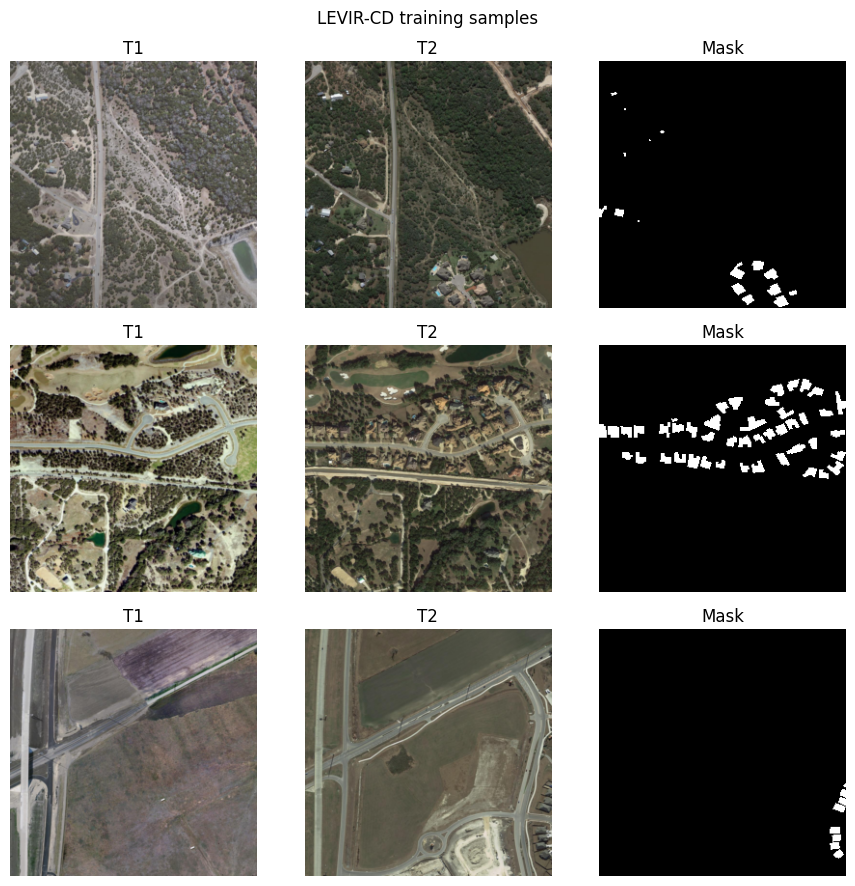

In [11]:
# ============================================================
# 10. Create dataloaders and inspect samples
# ============================================================
def get_loaders_for_dataset(dataset_name: str, batch_size=BATCH_SIZE, max_samples=MAX_SAMPLES_PER_SPLIT):
    train_df = make_split_df(samples_df, dataset_name, "train", require_mask=True, max_samples=max_samples)
    val_df = make_split_df(samples_df, dataset_name, "val", require_mask=True, max_samples=max_samples)
    test_df = make_split_df(samples_df, dataset_name, "test", require_mask=True, max_samples=max_samples)

    if len(val_df) == 0 and len(train_df) >= 10:
        val_df = train_df.sample(frac=0.2, random_state=SEED)
        train_df = train_df.drop(val_df.index).reset_index(drop=True)
        val_df = val_df.reset_index(drop=True)

    print(dataset_name, "train/val/test:", len(train_df), len(val_df), len(test_df))

    train_loader = DataLoader(ChangeDetectionDataset(train_df, IMG_SIZE, train=True), batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS) if len(train_df) else None
    val_loader = DataLoader(ChangeDetectionDataset(val_df, IMG_SIZE, train=False), batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS) if len(val_df) else None
    test_loader = DataLoader(ChangeDetectionDataset(test_df, IMG_SIZE, train=False, return_meta=True), batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS) if len(test_df) else None
    return train_loader, val_loader, test_loader, train_df, val_df, test_df

available_datasets = sorted(samples_df["dataset"].unique().tolist()) if len(samples_df) else []
print("Available paired datasets:", available_datasets)

SELECTED_DATASET = "LEVIR-CD" if "LEVIR-CD" in available_datasets else (available_datasets[0] if available_datasets else None)
print("SELECTED_DATASET:", SELECTED_DATASET)

if SELECTED_DATASET:
    train_loader, val_loader, test_loader, train_df, val_df, test_df = get_loaders_for_dataset(SELECTED_DATASET)

def show_batch(loader, n=3, title="Samples"):
    if loader is None:
        print("No loader.")
        return
    batch = next(iter(loader))
    x1 = batch["image_t1"]
    x2 = batch["image_t2"]
    y = batch["mask"]
    n = min(n, x1.shape[0])
    plt.figure(figsize=(9, 3*n))
    for i in range(n):
        plt.subplot(n, 3, i*3+1); plt.imshow(x1[i].permute(1,2,0)); plt.title("T1"); plt.axis("off")
        plt.subplot(n, 3, i*3+2); plt.imshow(x2[i].permute(1,2,0)); plt.title("T2"); plt.axis("off")
        plt.subplot(n, 3, i*3+3); plt.imshow(y[i,0], cmap="gray"); plt.title("Mask"); plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

if SELECTED_DATASET and train_loader:
    show_batch(train_loader, n=3, title=f"{SELECTED_DATASET} training samples")

## 9. Baseline training: Siamese U-Net

In [12]:
# ============================================================
# 11. Train Siamese U-Net baseline
# ============================================================
baseline_history = pd.DataFrame()
baseline_metrics = {}

if RUN_TRAINING and SELECTED_DATASET and train_loader:
    baseline_model = SiameseUNetBaseline(base=16, dropout=0.1).to(DEVICE)
    baseline_ckpt = CKPT_DIR / f"baseline_siamese_unet_{SELECTED_DATASET}.pt"
    baseline_history = train_one_model(
        baseline_model, train_loader, val_loader,
        epochs=EPOCHS, lr=LR, ckpt_path=baseline_ckpt,
        model_name=f"Baseline-{SELECTED_DATASET}"
    )
    baseline_history.to_csv(REPORT_DIR / f"baseline_history_{SELECTED_DATASET}.csv", index=False)
    if test_loader:
        baseline_metrics = evaluate_model(baseline_model, test_loader, DEVICE, mc_dropout_passes=1)
        print("Baseline test metrics:", baseline_metrics)
        pd.DataFrame([baseline_metrics]).to_csv(REPORT_DIR / f"baseline_test_metrics_{SELECTED_DATASET}.csv", index=False)

Baseline-LEVIR-CD epoch 1/2:   0%|          | 0/16 [00:00<?, ?it/s]

evaluate:   0%|          | 0/16 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.7545072250068188, 'val_precision': 0.0, 'val_recall': 0.0, 'val_f1': 0.0, 'val_iou': 0.0, 'val_overall_accuracy': 0.958028078079187, 'val_kappa': -3.813795412586964e-06, 'val_loss': 0.7251155227422714, 'val_ece': 0.3508577235043049, 'val_mc_uncertainty_mean': nan}


Baseline-LEVIR-CD epoch 2/2:   0%|          | 0/16 [00:00<?, ?it/s]

evaluate:   0%|          | 0/16 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.7044858038425446, 'val_precision': 0.4004383053744681, 'val_recall': 0.4047539041732207, 'val_f1': 0.37929358506461597, 'val_iou': 0.23977024540747136, 'val_overall_accuracy': 0.9501798152923221, 'val_kappa': 0.3548258638012344, 'val_loss': 0.6717021949589252, 'val_ece': 0.2870127884671092, 'val_mc_uncertainty_mean': nan}


evaluate:   0%|          | 0/16 [00:00<?, ?it/s]

Baseline test metrics: {'precision': 0.38595274285718895, 'recall': 0.36576115082808386, 'f1': 0.3610557004231624, 'iou': 0.22491475538844935, 'overall_accuracy': 0.937860965728724, 'kappa': 0.32900223596839384, 'loss': 0.6707563549280167, 'ece': 0.27789474558085203, 'mc_uncertainty_mean': nan}


## 10. Diffusion-style pseudo-change pretraining and proposed model fine-tuning

The proposal includes diffusion pseudo-change learning. This runnable notebook implements controlled pseudo-change edits first. You can later replace this with an actual diffusion/inpainting generator.

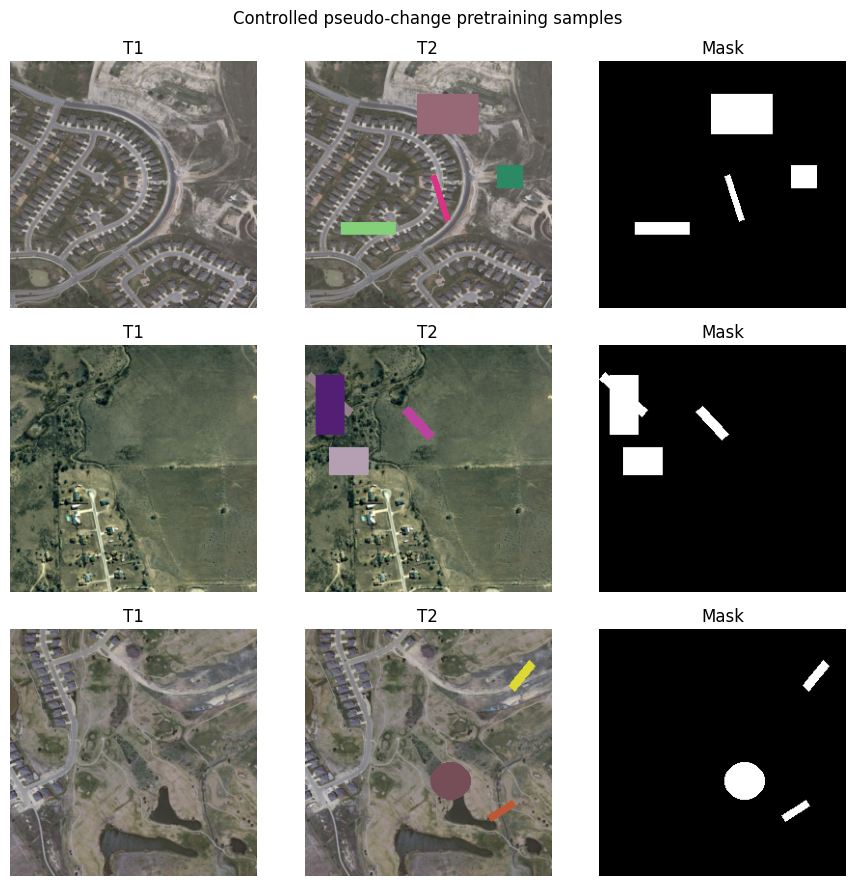

ObjChange-pretrain-LEVIR-CD epoch 1/2:   0%|          | 0/16 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.7337646447122097}


ObjChange-pretrain-LEVIR-CD epoch 2/2:   0%|          | 0/16 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.6454948522150517}


ObjChange-ft-LEVIR-CD epoch 1/2:   0%|          | 0/16 [00:00<?, ?it/s]

...

ObjChange-ft-LEVIR-CD epoch 2/2:   0%|          | 0/16 [00:00<?, ?it/s]

evaluate:   0%|          | 0/16 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.6739468686282635, 'val_precision': 0.46234901819502994, 'val_recall': 0.3221987282525259, 'val_f1': 0.3403143523866944, 'val_iou': 0.21064272752185473, 'val_overall_accuracy': 0.9546704292296999, 'val_kappa': 0.31979414745549883, 'val_loss': 0.6058472916483879, 'val_ece': 0.19625423848628998, 'val_mc_uncertainty_mean': nan}


evaluate:   0%|          | 0/16 [00:00<?, ?it/s]

Proposed test metrics: {'precision': 0.3868117808874584, 'recall': 0.5875524772993548, 'f1': 0.45153679002647995, 'iou': 0.295356503901078, 'overall_accuracy': 0.9340374469756724, 'kappa': 0.4184489569372306, 'loss': 0.6321161650121212, 'ece': 0.2291872575879097, 'mc_uncertainty_mean': 0.005950554157607257}


In [13]:
# ============================================================
# 12. Pseudo-change pretraining
# ============================================================
def make_pseudo_loader_from_dataset(dataset_name: str, max_samples=MAX_SAMPLES_PER_SPLIT, batch_size=BATCH_SIZE):
    df = make_split_df(samples_df, dataset_name, "train", require_mask=False, max_samples=max_samples)
    if len(df) == 0:
        return None
    ds = ChangeDetectionDataset(df, IMG_SIZE, train=True, pseudo_change=True)
    return DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)

pseudo_loader = make_pseudo_loader_from_dataset(SELECTED_DATASET) if SELECTED_DATASET else None
if pseudo_loader:
    show_batch(pseudo_loader, n=3, title="Controlled pseudo-change pretraining samples")

proposed_history_pre = pd.DataFrame()
proposed_history_ft = pd.DataFrame()
proposed_metrics = {}

if RUN_TRAINING and SELECTED_DATASET and train_loader:
    proposed_model = ObjChangeMambaDiffLite(base=16, dropout=0.15, token_grid=8).to(DEVICE)

    if pseudo_loader:
        proposed_history_pre = train_one_model(
            proposed_model, pseudo_loader, val_loader=None,
            epochs=max(1, EPOCHS), lr=LR,
            model_name=f"ObjChange-pretrain-{SELECTED_DATASET}"
        )
        proposed_history_pre.to_csv(REPORT_DIR / f"proposed_pseudo_pretrain_history_{SELECTED_DATASET}.csv", index=False)

    proposed_ckpt = CKPT_DIR / f"objchange_mambadiff_lite_{SELECTED_DATASET}.pt"
    proposed_history_ft = train_one_model(
        proposed_model, train_loader, val_loader,
        epochs=EPOCHS, lr=LR, ckpt_path=proposed_ckpt,
        model_name=f"ObjChange-ft-{SELECTED_DATASET}"
    )
    proposed_history_ft.to_csv(REPORT_DIR / f"proposed_finetune_history_{SELECTED_DATASET}.csv", index=False)

    if test_loader:
        proposed_metrics = evaluate_model(proposed_model, test_loader, DEVICE, mc_dropout_passes=5)
        print("Proposed test metrics:", proposed_metrics)
        pd.DataFrame([proposed_metrics]).to_csv(REPORT_DIR / f"proposed_test_metrics_{SELECTED_DATASET}.csv", index=False)

## 11. Main result table

In [14]:
# ============================================================
# 13. Compare baseline vs proposed
# ============================================================
result_rows = []
if baseline_metrics:
    r = {"dataset": SELECTED_DATASET, "model": "SiameseUNetBaseline"}
    r.update(baseline_metrics)
    result_rows.append(r)
if proposed_metrics:
    r = {"dataset": SELECTED_DATASET, "model": "ObjChangeMambaDiffLite"}
    r.update(proposed_metrics)
    result_rows.append(r)

main_results_df = pd.DataFrame(result_rows)
if len(main_results_df):
    main_results_df.to_csv(REPORT_DIR / f"main_results_{SELECTED_DATASET}.csv", index=False)
    display(main_results_df)
else:
    print("No results yet. Ensure RUN_TRAINING=True and paired datasets/masks are available.")

,dataset,model,precision,recall,f1,iou,overall_accuracy,kappa,loss,ece,mc_uncertainty_mean
0,LEVIR-CD,SiameseUNetBaseline,0.385953,0.365761,0.361056,0.224915,0.937861,0.329002,0.670756,0.277895,NaN
1,LEVIR-CD,ObjChangeMambaDiffLite,0.386812,0.587552,0.451537,0.295357,0.934037,0.418449,0.632116,0.229187,0.005951


## 12. Qualitative predictions

In [15]:
# ============================================================
# 14. Qualitative prediction figures
# ============================================================
@torch.no_grad()
def save_qualitative_predictions(model, loader, out_dir: Path, n_batches=2, mc_passes=5):
    if model is None or loader is None:
        return
    out_dir.mkdir(parents=True, exist_ok=True)
    model.eval()
    saved = 0
    for bi, batch in enumerate(loader):
        if bi >= n_batches:
            break
        x1 = batch["image_t1"].to(DEVICE)
        x2 = batch["image_t2"].to(DEVICE)
        y = batch["mask"].to(DEVICE)

        if mc_passes > 1:
            model.train()
            logits_list = [model(x1, x2) for _ in range(mc_passes)]
            model.eval()
            stack = torch.stack(logits_list, dim=0)
            prob = torch.sigmoid(stack).mean(dim=0)
            unc = torch.sigmoid(stack).var(dim=0)
        else:
            prob = torch.sigmoid(model(x1, x2))
            unc = torch.zeros_like(prob)

        for i in range(x1.shape[0]):
            fig, axes = plt.subplots(1, 6, figsize=(18, 3))
            axes[0].imshow(x1[i].cpu().permute(1,2,0)); axes[0].set_title("T1")
            axes[1].imshow(x2[i].cpu().permute(1,2,0)); axes[1].set_title("T2")
            axes[2].imshow(y[i,0].cpu(), cmap="gray"); axes[2].set_title("Ground truth")
            axes[3].imshow(prob[i,0].cpu(), cmap="viridis"); axes[3].set_title("Probability")
            axes[4].imshow((prob[i,0].cpu() > 0.5), cmap="gray"); axes[4].set_title("Prediction")
            axes[5].imshow(unc[i,0].cpu(), cmap="magma"); axes[5].set_title("Uncertainty")
            for ax in axes:
                ax.axis("off")
            plt.tight_layout()
            fname = out_dir / f"qualitative_{saved:04d}.png"
            plt.savefig(fname, dpi=160, bbox_inches="tight")
            plt.close(fig)
            saved += 1
    print("Saved qualitative figures:", saved, "to", out_dir)

if RUN_TRAINING and SELECTED_DATASET and test_loader and "proposed_model" in globals():
    save_qualitative_predictions(proposed_model, test_loader, PRED_DIR / SELECTED_DATASET, n_batches=2, mc_passes=5)

Saved qualitative figures: 8 to D:\Datasets\Satillate\_objchange_mambadiff_project\qualitative_predictions\LEVIR-CD


## 13. Label-efficiency experiments

Run 1%, 5%, 10%, 25%, 50%, and 100% labelled training data. For publication, use three or more seeds.

In [16]:
# ============================================================
# 15. Label-efficiency experiment
# ============================================================
def sample_fraction_df(df: pd.DataFrame, fraction: float, seed: int=SEED) -> pd.DataFrame:
    if len(df) == 0:
        return df
    n = max(1, int(len(df) * fraction))
    return df.sample(n=n, random_state=seed).reset_index(drop=True)

def run_label_efficiency(dataset_name: str, fractions=[0.01, 0.05, 0.10, 0.25, 0.50, 1.0], seeds=[42]):
    full_train = make_split_df(samples_df, dataset_name, "train", require_mask=True, max_samples=None if not QUICK_RUN else MAX_SAMPLES_PER_SPLIT)
    val_df = make_split_df(samples_df, dataset_name, "val", require_mask=True, max_samples=MAX_SAMPLES_PER_SPLIT)
    test_df = make_split_df(samples_df, dataset_name, "test", require_mask=True, max_samples=MAX_SAMPLES_PER_SPLIT)

    if len(full_train) == 0 or len(test_df) == 0:
        print("Insufficient data for label-efficiency:", dataset_name)
        return pd.DataFrame()

    val_loader_local = DataLoader(ChangeDetectionDataset(val_df, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS) if len(val_df) else None
    test_loader_local = DataLoader(ChangeDetectionDataset(test_df, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    rows = []
    for seed in seeds:
        for frac in fractions:
            tr_df = sample_fraction_df(full_train, frac, seed)
            tr_loader = DataLoader(ChangeDetectionDataset(tr_df, IMG_SIZE, train=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            model = ObjChangeMambaDiffLite(base=16, dropout=0.15).to(DEVICE)
            pseudo_loader_local = make_pseudo_loader_from_dataset(dataset_name, max_samples=len(tr_df), batch_size=BATCH_SIZE)
            if pseudo_loader_local:
                _ = train_one_model(model, pseudo_loader_local, None, epochs=1 if QUICK_RUN else 5, lr=LR, model_name=f"LE-pre-{frac}")
            _ = train_one_model(model, tr_loader, val_loader_local, epochs=1 if QUICK_RUN else EPOCHS, lr=LR, model_name=f"LE-ft-{frac}")
            metrics = evaluate_model(model, test_loader_local, DEVICE, mc_dropout_passes=3)
            row = {"dataset": dataset_name, "seed": seed, "fraction": frac, "n_train": len(tr_df), "model": "ObjChangeMambaDiffLite+pseudo"}
            row.update(metrics)
            rows.append(row)
            print(row)

    out = pd.DataFrame(rows)
    out.to_csv(REPORT_DIR / f"label_efficiency_{dataset_name}.csv", index=False)
    return out

# Uncomment:
# label_eff_df = run_label_efficiency(
#     SELECTED_DATASET,
#     fractions=[0.05, 0.10, 0.25, 1.0] if QUICK_RUN else [0.01,0.05,0.10,0.25,0.50,1.0],
#     seeds=[42] if QUICK_RUN else [42,43,44]
# )
# display(label_eff_df)

## 14. Cross-dataset generalisation

In [17]:
# ============================================================
# 16. Cross-dataset evaluation helper
# ============================================================
def train_on_one_test_many(train_dataset: str, test_datasets: List[str], epochs=EPOCHS):
    tr_loader, val_loader, _, _, _, _ = get_loaders_for_dataset(train_dataset)
    if tr_loader is None:
        print("No training loader for", train_dataset)
        return pd.DataFrame()

    model = ObjChangeMambaDiffLite(base=16, dropout=0.15).to(DEVICE)
    _ = train_one_model(model, tr_loader, val_loader, epochs=epochs, lr=LR, model_name=f"cross-train-{train_dataset}")

    rows = []
    for td in test_datasets:
        _, _, te_loader, _, _, _ = get_loaders_for_dataset(td)
        if te_loader is None:
            print("No test loader for", td)
            continue
        metrics = evaluate_model(model, te_loader, DEVICE, mc_dropout_passes=3)
        row = {"train_dataset": train_dataset, "test_dataset": td, "model": "ObjChangeMambaDiffLite"}
        row.update(metrics)
        rows.append(row)
    out = pd.DataFrame(rows)
    out.to_csv(REPORT_DIR / f"cross_dataset_train_{train_dataset}.csv", index=False)
    return out

# Uncomment examples:
# if "LEVIR-CD" in available_datasets:
#     cross_df = train_on_one_test_many("LEVIR-CD", [d for d in ["S2Looking", "WHU-CD"] if d in available_datasets], epochs=1 if QUICK_RUN else EPOCHS)
#     display(cross_df)
#
# if "DSIFN-CD" in available_datasets:
#     cross_df2 = train_on_one_test_many("DSIFN-CD", [d for d in ["CDD"] if d in available_datasets], epochs=1 if QUICK_RUN else EPOCHS)
#     display(cross_df2)

## 15. Ablation study

Implemented ablations:

- A0: Siamese U-Net
- A2: Shared encoder without object tokens
- A3/A4/A5-lite: Object-token attention with Mamba-like memory
- A6/A7: Pseudo-change pretraining + uncertainty

In [18]:
# ============================================================
# 17. Ablation variants
# ============================================================
class ObjChangeNoObject(nn.Module):
    def __init__(self, base=32, dropout=0.15):
        super().__init__()
        self.encoder = EncoderSmall(3, base, dropout=dropout)
        ch = base * 8
        self.fuse_bottleneck = ConvBlock(ch*3, ch, dropout)
        self.up3 = UpBlock(ch, base*4*3, base*4, dropout)
        self.up2 = UpBlock(base*4, base*2*3, base*2, dropout)
        self.up1 = UpBlock(base*2, base*1*3, base, dropout)
        self.head = nn.Conv2d(base, 1, 1)
    def interact(self, a, b):
        return torch.cat([a, b, torch.abs(a-b)], dim=1)
    def forward(self, x1, x2):
        f1, f2 = self.encoder(x1), self.encoder(x2)
        s1, s2, s3, s4 = [self.interact(a,b) for a,b in zip(f1, f2)]
        x = self.fuse_bottleneck(s4)
        x = self.up3(x, s3)
        x = self.up2(x, s2)
        x = self.up1(x, s1)
        return self.head(x)

def run_ablation(dataset_name: str):
    tr_loader, val_loader, te_loader, *_ = get_loaders_for_dataset(dataset_name)
    if tr_loader is None or te_loader is None:
        return pd.DataFrame()

    variants = {
        "A0_SiameseUNet": SiameseUNetBaseline(base=16, dropout=0.1),
        "A2_SharedEncoder_NoObject": ObjChangeNoObject(base=16, dropout=0.15),
        "A3_A4_A5_ObjectMambaTokens": ObjChangeMambaDiffLite(base=16, dropout=0.15),
    }
    rows = []
    for name, model in variants.items():
        model = model.to(DEVICE)
        _ = train_one_model(model, tr_loader, val_loader, epochs=1 if QUICK_RUN else EPOCHS, lr=LR, model_name=name)
        metrics = evaluate_model(model, te_loader, DEVICE, mc_dropout_passes=1)
        row = {"dataset": dataset_name, "ablation": name}
        row.update(metrics)
        rows.append(row)

    model = ObjChangeMambaDiffLite(base=16, dropout=0.15).to(DEVICE)
    pseudo = make_pseudo_loader_from_dataset(dataset_name)
    if pseudo:
        _ = train_one_model(model, pseudo, None, epochs=1 if QUICK_RUN else 5, lr=LR, model_name="A6_pseudo_pretrain")
    _ = train_one_model(model, tr_loader, val_loader, epochs=1 if QUICK_RUN else EPOCHS, lr=LR, model_name="A6_finetune")
    metrics = evaluate_model(model, te_loader, DEVICE, mc_dropout_passes=5)
    row = {"dataset": dataset_name, "ablation": "A6_A7_PseudoPretrain_Uncertainty"}
    row.update(metrics)
    rows.append(row)

    out = pd.DataFrame(rows)
    out.to_csv(REPORT_DIR / f"ablation_{dataset_name}.csv", index=False)
    return out

# Uncomment:
# ablation_df = run_ablation(SELECTED_DATASET)
# display(ablation_df)

## 16. Boundary F1 and small-object analysis

In [19]:
# ============================================================
# 18. Boundary F1 metric
# ============================================================
def binary_erosion_np(mask: np.ndarray, k=3):
    pad = k // 2
    padded = np.pad(mask, pad, mode="constant")
    out = np.ones_like(mask)
    for dy in range(k):
        for dx in range(k):
            out &= padded[dy:dy+mask.shape[0], dx:dx+mask.shape[1]]
    return out

def boundary_map(mask: np.ndarray, k=3):
    mask = (mask > 0).astype(np.uint8)
    er = binary_erosion_np(mask, k)
    return mask ^ er

def boundary_f1(pred: np.ndarray, gt: np.ndarray, k=3):
    pb = boundary_map(pred, k)
    gb = boundary_map(gt, k)
    tp = (pb & gb).sum()
    fp = (pb & (1-gb)).sum()
    fn = ((1-pb) & gb).sum()
    eps = 1e-8
    p = tp / (tp + fp + eps)
    r = tp / (tp + fn + eps)
    return 2*p*r/(p+r+eps)

@torch.no_grad()
def evaluate_boundary_f1(model, loader, max_batches=10):
    model.eval()
    vals = []
    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break
        x1, x2, y = batch["image_t1"].to(DEVICE), batch["image_t2"].to(DEVICE), batch["mask"].to(DEVICE)
        prob = torch.sigmoid(model(x1, x2))
        pred = (prob > 0.5).cpu().numpy()
        gt = (y > 0.5).cpu().numpy()
        for i in range(pred.shape[0]):
            vals.append(boundary_f1(pred[i,0].astype(np.uint8), gt[i,0].astype(np.uint8)))
    return float(np.mean(vals)) if vals else np.nan

# Example:
# if RUN_TRAINING and test_loader and "proposed_model" in globals():
#     print("Boundary F1:", evaluate_boundary_f1(proposed_model, test_loader))

## 17. Export final research package summary

In [20]:
# ============================================================
# 19. Export final summary files
# ============================================================
summary = {
    "root": str(ROOT),
    "project_dir": str(PROJECT_DIR),
    "device": DEVICE,
    "quick_run": QUICK_RUN,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "detected_datasets": available_datasets,
    "reports": {
        "detected_dataset_roots": str(REPORT_DIR / "detected_dataset_roots.csv"),
        "full_inventory": str(REPORT_DIR / "full_inventory.csv"),
        "unified_samples": str(REPORT_DIR / "unified_samples_after_manual_pairing.csv"),
    },
}
with open(REPORT_DIR / "research_run_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("\\nReports saved to:", REPORT_DIR)
print("Checkpoints saved to:", CKPT_DIR)
print("Figures saved to:", FIG_DIR)
print("Qualitative predictions saved to:", PRED_DIR)

{
  "root": "D:\\Datasets\\Satillate",
  "project_dir": "D:\\Datasets\\Satillate\\_objchange_mambadiff_project",
  "device": "cuda",
  "quick_run": true,
  "img_size": 256,
  "batch_size": 4,
  "epochs": 2,
  "detected_datasets": [
    "DSIFN-CD",
    "LEVIR-CD",
    "S2Looking",
    "SECOND",
    "xView2"
  ],
  "reports": {
    "detected_dataset_roots": "D:\\Datasets\\Satillate\\_objchange_mambadiff_project\\reports\\detected_dataset_roots.csv",
    "full_inventory": "D:\\Datasets\\Satillate\\_objchange_mambadiff_project\\reports\\full_inventory.csv",
    "unified_samples": "D:\\Datasets\\Satillate\\_objchange_mambadiff_project\\reports\\unified_samples_after_manual_pairing.csv"
  }
}
\nReports saved to: D:\Datasets\Satillate\_objchange_mambadiff_project\reports
Checkpoints saved to: D:\Datasets\Satillate\_objchange_mambadiff_project\checkpoints
Figures saved to: D:\Datasets\Satillate\_objchange_mambadiff_project\figures
Qualitative predictions saved to: D:\Datasets\Satillate\_objcha

## 18. Recommended full-run settings for publication

After the quick run works correctly, use:

```python
QUICK_RUN = False
EPOCHS = 50
BATCH_SIZE = 8 or 16
MAX_SAMPLES_PER_SPLIT = None
NUM_WORKERS = 2 or 4
```

Recommended experiment order:

1. Validate samples visually for LEVIR-CD, S2Looking, DSIFN-CD, CDD, SECOND, HRSCD, and xView2.
2. Train A0 Siamese U-Net baseline on LEVIR-CD.
3. Train ObjChange-MambaDiff-Lite on LEVIR-CD.
4. Run ablation on LEVIR-CD and S2Looking.
5. Run label-efficiency on LEVIR-CD and CDD.
6. Run cross-dataset generalisation:
   - LEVIR-CD → S2Looking
   - DSIFN-CD → CDD
   - SECOND → HRSCD if labels are mapped
7. Preprocess xView2 masks and run disaster experiments.
8. Save qualitative maps and boundary metrics.
9. Write the manuscript with dataset governance and reproducibility tables.